In [1]:
pip install epyt_flow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 855.9/855.9 kB 18.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 15.8 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 21.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 38.8 MB/s  0:00:00
  Attempting uninstall: dill0m╺━━━━━━━━━━━━━━━━━━━━━━━━━━  4/12 [falcon]]
    Found existing installation: dill 0.4.0━━━━━━━━━━━━━━━━━━━  4/12 [falcon]
    Uninstalling dill-0.4.0:━━━━━━━━━━━━━━━━━━━━━━━━━━  4/12 [falcon]
      Successfully uninstalled dill-0.4.0━━━━━━━━━━━━━━━━━━━━━  4/12 [falcon]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12/12 [epyt_flow]12 [epyt_flow]
Note: you may need to restart the kernel to use updated packages.


  Page 1                                    Sun Aug  9 12:50:08 2026

  ******************************************************************
  *                           E P A N E T                          *
  *                   Hydraulic and Water Quality                  *
  *                   Analysis for Pipe Networks                   *
  *                          Version 2.3.06                        *
  ******************************************************************
    Page 1                                    Sun Aug  9 12:50:10 2026

  ******************************************************************
  *                           E P A N E T                          *
  *                   Hydraulic and Water Quality                  *
  *                   Analysis for Pipe Networks                   *
  *                          Version 2.3.06                        *
  ******************************************************************
    Page 1                    

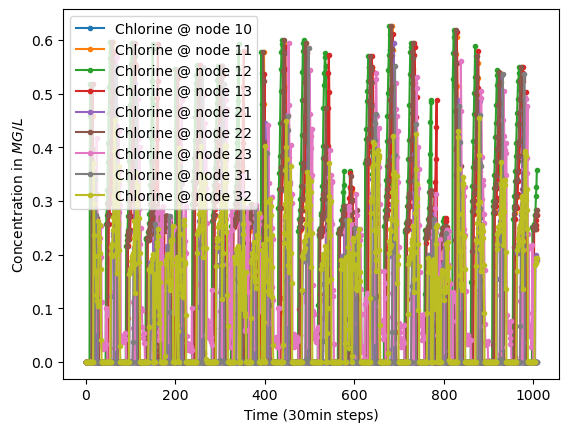

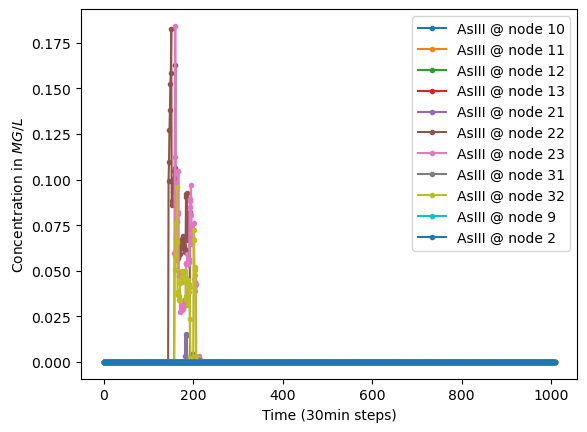

['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'batadal', 'batadal_data', 'battledim', 'battledim_data', 'compute_battledim_evaluation_score', 'compute_leakdb_evaluation_score', 'gecco_water_quality', 'leakdb', 'leakdb_data', 'load_batadal_data', 'load_batadal_scada_data', 'load_batadal_scenario', 'load_battledim_data', 'load_battledim_scada_data', 'load_battledim_scenario', 'load_gecco2017_water_quality_data', 'load_gecco2018_water_quality_data', 'load_gecco2019_water_quality_data', 'load_leakdb_data', 'load_leakdb_scada_data', 'load_leakdb_scenarios', 'load_water_usage', 'water_usage']


In [3]:
import numpy as np
from epyt_flow.data.benchmarks import load_leakdb_scenarios
from epyt_flow.simulation import ScenarioSimulator, EpanetConstants, ScenarioConfig
from epyt_flow.simulation.events import SpeciesInjectionEvent
from epyt_flow.utils import to_seconds
import epyt_flow.data.benchmarks as benchmarks


if __name__ == "__main__":
    # Create a new scenario based on the first Net1 LeakDB scenario --
    # we add an additional EPANET-MSX configuration file
    config, = load_leakdb_scenarios(scenarios_id=["1"], use_net1=True)
    config = ScenarioConfig(scenario_config=config,
                            f_msx_in="arsenic_contamination.msx")

    with ScenarioSimulator(scenario_config=config) as sim:
        # Set simulation duration to 21 days
        sim.set_general_parameters(simulation_duration=to_seconds(days=21))

        # Place some chlorine sensors and also keep track of the contaminant
        cl_sensor_locations = ["10", "11", "12", "13", "21", "22", "23", "31", "32"]
        all_nodes = sim.sensor_config.nodes
        sim.set_bulk_species_node_sensors({"Chlorine": cl_sensor_locations,
                                           # Also: Keep track of the contaminant
                                           "AsIII": all_nodes})   # Arsenite

        # Create a 1-day contamination event --
        # i.e. injection of Arsenite (100mg/L) at node "22"
        contamination_event = SpeciesInjectionEvent(species_id="AsIII", node_id="22",
                                                    profile=np.array([100]),
                                                    source_type=EpanetConstants.EN_MASS,
                                                    start_time=to_seconds(days=3),
                                                    end_time=to_seconds(days=4))
        sim.add_system_event(contamination_event)

        # Run simulation
        scada_data = sim.run_simulation()
        flows = scada_data.get_data_flows()

        print(type(flows))
        print()

        print(flows)
        chlorine = scada_data.get_data_bulk_species_node_concentration({"Chlorine": cl_sensor_locations})

        print(type(chlorine))
        print()

        print(chlorine)

        df = scada_data.to_pandas_dataframe()

        print(scada_data.sensor_readings_time[:10])
        print(len(scada_data.sensor_readings_time))
        print(scada_data.sensor_readings_time[-1])

        # Inspect simulation results -- i.e. sensor readings over time
        scada_data.plot_bulk_species_node_concentration({"Chlorine": cl_sensor_locations})
        scada_data.plot_bulk_species_node_concentration({"AsIII": all_nodes})



print(dir(benchmarks))